# CAPM

This notebook summarizes the implications of CAPM and then tests them by OLS.

## Load Packages and Extra Functions

In [1]:
using Printf, DelimitedFiles, Statistics

include("src/printmat.jl")
include("src/OlsGMNW.jl");            #contains a function for OLS

In [2]:
using Plots, LaTeXStrings
default(size = (480,320),fmt = :png)

# The Theoretical Predictions of CAPM

The following section illustrates the theoretical predictions of CAPM by taking the following steps: 

1. define a set of investable assets
2. find the tangency portfolio
3. calculate the betas of each asset against the tangency portfolio
4. check whether the average returns are in accordance with CAPM:  $\text{E}R_{i}  = R_f + \beta_{i}(\mu_{T}-R_f)$ or equivalently $\text{E}R_i^e  = \beta_i \mu_T^e$, where superscript $^e$ indicates an excess return.

## Characteristics of Three Assets: Means, Variances and Covariances

In [3]:
μ = [0.115, 0.095, 0.06]    #expected returns
Σ = [166  34  58;           #covariance matrix
      34  64   4;
      58   4 100]/100^2
Rf = 0.03

assetNames = ["A","B","C"]

printblue("expected returns, in %:")
printmat(μ*100;rowNames=assetNames)

printblue("covariance matrix, in bp:")
printmat(Σ*10_000;colNames=assetNames,rowNames=assetNames)

expected returns, in %:
A    11.500
B     9.500
C     6.000

covariance matrix, in bp:
          A         B         C
A   166.000    34.000    58.000
B    34.000    64.000     4.000
C    58.000     4.000   100.000



## The Tangency Portfolio

The file included below contains, among other things, the function `MVTangencyP()` from the chapter on MV analysis. It calcuates the tangency portfolio.

In [4]:
include("src/MvCalculations.jl");

In [5]:
(wT,μT,σT) = MVTangencyP(μ,Σ,Rf)          #tangency portfolio weights and implied mean return and standard deviation
printblue("Tangency portfolio weights:")
printmat(wT;rowNames=assetNames)

printblue("mean and std of tangency portfolio:")
printmat([μT,σT];rowNames=["μT","σT"])

Tangency portfolio weights:
A     0.248
B     0.682
C     0.070

mean and std of tangency portfolio:
μT     0.097
σT     0.074



## β of the Assets (Theory)

1. The foc for optimal portfolio choice says: $\mathrm{E}R^e= c k\Sigma w_T$, where $w_T$ is the tangency portfolio.
2. The covariance of $R_i$ and $R_T$ ($\sigma_{iT}$) is the $i$th row of $\Sigma w_T$. (Alternatively, $w_i \Sigma w_T$, where $w_i$ has 1 in position $i$ and 0 elsewhere.)
3. Rewrite and calculate $\beta_i = \sigma_{iT}/\sigma_{T}^2$.
4. CAPM: $\mathrm{E}R_i^e = \beta_i R_T^e$.

In [6]:
β = Σ*wT/σT^2                   #vector of betas
ER_CAPM = Rf .+ β*(μT-Rf)       #ER_CAPM is a vector since β is a vector

b = range(0,2,length=5)
SML = Rf .+ b*(μT-Rf)       #SML

printblue("β and ER according to CAPM: ")
printmat(β,ER_CAPM;rowNames=assetNames,colNames=["β","ERᵉ (CAPM)"],width=15)

β and ER according to CAPM: 
               β     ERᵉ (CAPM)
A          1.259          0.115
B          0.963          0.095
C          0.444          0.060



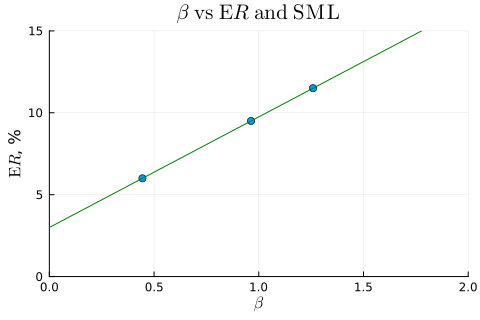

In [7]:
p1 = scatter( β,ER_CAPM*100,      #points on the security market line
              xlim = (0,2),
              ylim = (0,15),
              legend = false,
              title = L"\beta \mathrm{\ vs\ E}R \mathrm{\ and \ SML}",
              xlabel = L"\beta",
              ylabel = L"$\mathrm{E}R$, %" )
Plots.abline!((μT-Rf)*100,Rf*100,linecolor=:green,line=:solid)
display(p1)

# An Empirical Test of CAPM 

The next section performs an empirical test of CAPM. First, we load data. Then, we run linear regressions and test whether the intercepts are zero (the CAPM prediction) or not. (We test each asset separately.)

## Loading Data

We load data from two data files: for the returns on Fama-French equity factors and then also for the 25 Fama-French portfolios. To keep the output simple, we use only 5 of those return series.

In [8]:
x    = readdlm("Data/FFmFactorsPs.csv",',',skipstart=1)
Rme  = x[:,2]                #market excess return
RSMB = x[:,3]                #small minus big firms
RHML = x[:,4]                #high minus low book-to-market ratio
Rf   = x[:,5]                #interest rate


x  = readdlm("Data/25_Portfolios_5x5.CSV",',',skipstart=1)
R  = x[:,2:end]                     #returns for 25 FF portfolios
Re = R .- Rf                        #excess returns for the 25 FF portfolios
Re = Re[:,[1,7,13,19,25]]           #use just 5 assets to make the printing easier

(T,n) = size(Re)                    #no. obs and  no. test assets

AssetNames = string.("Asset ",[1,7,13,19,25]);

## OLS Estimation and Testing α = 0

We now use the market return as a proxy for the tangency portfolio - and test if CAPM holds for the test assets.

To do that, we estimate $(\alpha_{i},b_{i})$ in the CAPM regression

$R_{it}^{e}  =\alpha_{i}+\beta_{i}R_{mt}^{e}+\varepsilon_{it}$,

where $R_{it}^{e}$ and $R_{mt}^{e}$ are excess return, and then test if $\alpha_{i}=0$. This corresponds to the CAPM prediction that $\text{E}R_i^e  = \beta_i \mu_m^e$. Compared with the theoretical expression above, we use the market excess return as a measure of the excess return of the tangency portfolio.


### A Remark on the Code

- The function `OlsNW` is included in the file `Ols.jl` (see the first cell of the notebook). It does OLS estimation and reports the point estimates, residuals and more. The variance-covariance matrix of the coefficients is based on the Gauss-Markov assumptions.
- In the call on `printmat()`, `;rowNames` (notice: semicolon) is the same as `,rowNames=rowNames`.

In [9]:
x = [ones(T) Rme]                   #regressors

(α,tstat) = (fill(NaN,n),fill(NaN,n))
for i in 1:n                              #loop over the different test assets
    #local b_i, residual, Covb           #local/global is needed in script
    (b_i,_,_,Covb,) = OlsNW(Re[:,i],x,1)
    α[i]            = b_i[1]                      #estimated α
    tstat[i]        = (α[i]-0)/sqrt(Covb[1,1])    #t-stat of H₀: true α=0
end

printblue("OLS intercepts and t-stats:")
rowNames = ["α","t-stat"]
printmat([α';tstat'];colNames=AssetNames,rowNames)

OLS intercepts and t-stats:
         Asset 1   Asset 7  Asset 13  Asset 19  Asset 25
α         -0.687     0.062     0.112     0.218     0.149
t-stat    -3.447     0.525     1.200     2.061     0.971

